<a href="https://colab.research.google.com/github/abinayanand7896-cloud/Data-Augmentation-comparison/blob/main/creditcard_augmentation_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Experiment for Credit Card Fraud Dataset**

In [13]:
!pip install scikit-learn imbalanced-learn ctgan sdv xgboost pandas numpy openpyxl

**1. Importing Libraries**

In [14]:
import pandas as pd
import numpy as np
import os
import json
import warnings
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from ctgan import CTGAN
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

**2. Data Loading and Setup**

In [15]:
fraud_df = pd.read_csv('creditcard.csv')
print(f"Fraud Detection shape: {fraud_df.shape}")

fraud_target = 'Class' if 'Class' in fraud_df.columns else fraud_df.columns[-1]
print(f"Fraud target: '{fraud_target}'")
print(f"Class distribution:{fraud_df[fraud_target].value_counts()}")

Fraud Detection shape: (284807, 31)
Fraud target: 'Class'
Class distribution:Class
0    284315
1       492
Name: count, dtype: int64


**3. Creating Imbalanced Datasets for the ratios(1:10, 1:100, 1:1000)**

In [16]:
def create_imbalanced_dataset(df, target_col, ratio, dataset_name):
    minority_class = df[target_col].value_counts().idxmin()
    majority_class = df[target_col].value_counts().idxmax()

    minority_samples = df[df[target_col] == minority_class]
    majority_samples = df[df[target_col] == majority_class]

    n_minority = len(minority_samples)
    n_majority_target = n_minority * ratio

    print(f"Creating {dataset_name} with 1:{ratio} ratio")
    print(f"Minority class ({minority_class}): {n_minority} samples")
    print(f"Target majority samples: {n_majority_target}")

    if len(majority_samples) >= n_majority_target:
        majority_selected = majority_samples.sample(n=n_majority_target, random_state=42)
        print(f"Subsampled majority class to {len(majority_selected)} samples")
    else:
        n_repeats = int(np.ceil(n_majority_target / len(majority_samples)))
        majority_repeated = pd.concat([majority_samples] * n_repeats, ignore_index=True)
        majority_selected = majority_repeated.sample(n=n_majority_target, random_state=42)
        print(f"Bootstrapped majority class to {len(majority_selected)} samples (repeated {n_repeats} times)")

    imbalanced_df = pd.concat([minority_samples, majority_selected], ignore_index=True)
    imbalanced_df = imbalanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Final dataset shape: {imbalanced_df.shape}")
    print(f"Final class distribution: {imbalanced_df[target_col].value_counts().to_dict()}")

    return imbalanced_df


ratios = [10, 100, 1000]
os.makedirs('creditcard_imbalanced_datasets', exist_ok=True)

print("CREATING CREDIT CARD IMBALANCED DATASETS")

for ratio in ratios:
    imbalanced_cc = create_imbalanced_dataset(fraud_df, fraud_target, ratio, f"Credit Card 1:{ratio}")
    filename = f"creditcard_imbalanced_datasets/creditcard_1_{ratio}.csv"
    imbalanced_cc.to_csv(filename, index=False)
    print(f"Saved: {filename}")

CREATING CREDIT CARD IMBALANCED DATASETS
Creating Credit Card 1:10 with 1:10 ratio
Minority class (1): 492 samples
Target majority samples: 4920
Subsampled majority class to 4920 samples
Final dataset shape: (5412, 31)
Final class distribution: {0: 4920, 1: 492}
Saved: creditcard_imbalanced_datasets/creditcard_1_10.csv
Creating Credit Card 1:100 with 1:100 ratio
Minority class (1): 492 samples
Target majority samples: 49200
Subsampled majority class to 49200 samples
Final dataset shape: (49692, 31)
Final class distribution: {0: 49200, 1: 492}
Saved: creditcard_imbalanced_datasets/creditcard_1_100.csv
Creating Credit Card 1:1000 with 1:1000 ratio
Minority class (1): 492 samples
Target majority samples: 492000
Bootstrapped majority class to 492000 samples (repeated 2 times)
Final dataset shape: (492492, 31)
Final class distribution: {0: 492000, 1: 492}
Saved: creditcard_imbalanced_datasets/creditcard_1_1000.csv


**4. Defining Classifiers**

In [17]:
def get_classifiers():
    return {
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss',
                                 random_state=42, use_label_encoder=False)
    }

print("Fixed classifiers defined:")
for name, clf in get_classifiers().items():
    print(f"- {name}: {clf}")

Fixed classifiers defined:
- LogisticRegression: LogisticRegression(max_iter=1000, random_state=42)
- RandomForest: RandomForestClassifier(random_state=42)
- XGBoost: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


**5. Defining Augmentation Parameters(2 variations)**

In [18]:
def get_augmentation_configs():
    return {
        'V1_Default': {
            'SMOTE': {'k_neighbors': 5, 'sampling_strategy': 'auto', 'random_state': 42},
            'ADASYN': {'n_neighbors': 5, 'sampling_strategy': 'auto', 'random_state': 42},
            'CTGAN': {'epochs': 100, 'batch_size': 250, 'pac':10, 'verbose':True}
        },
        'V2_Tuned': {
            'SMOTE': {'k_neighbors': 3, 'sampling_strategy': 0.5, 'random_state': 42},
            'ADASYN': {'n_neighbors': 10, 'sampling_strategy': 0.5, 'random_state': 42},
            'CTGAN': {'epochs': 150, 'batch_size': 500, 'pac':10, 'verbose':True}
        }
    }

configs = get_augmentation_configs()
print("Augmentation configurations:")
for variation, methods in configs.items():
    print(f"{variation}:")
    for method, params in methods.items():
        print(f"  {method}: {params}")

Augmentation configurations:
V1_Default:
  SMOTE: {'k_neighbors': 5, 'sampling_strategy': 'auto', 'random_state': 42}
  ADASYN: {'n_neighbors': 5, 'sampling_strategy': 'auto', 'random_state': 42}
  CTGAN: {'epochs': 100, 'batch_size': 250, 'pac': 10, 'verbose': True}
V2_Tuned:
  SMOTE: {'k_neighbors': 3, 'sampling_strategy': 0.5, 'random_state': 42}
  ADASYN: {'n_neighbors': 10, 'sampling_strategy': 0.5, 'random_state': 42}
  CTGAN: {'epochs': 150, 'batch_size': 500, 'pac': 10, 'verbose': True}


**6. Training and Evaluation Pipeline**

In [19]:
def evaluate_model(clf, X_test, y_test):
    try:
        y_pred = clf.predict(X_test)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]

        metrics = {
            'F1': round(f1_score(y_test, y_pred, pos_label=1), 4),
            'Precision': round(precision_score(y_test, y_pred, pos_label=1), 4),
            'Recall': round(recall_score(y_test, y_pred, pos_label=1), 4),
            'AUC-ROC': round(roc_auc_score(y_test, y_pred_proba), 4)
        }
        return metrics, y_pred_proba
    except Exception as e:
        print(f"Error in evaluation: {str(e)}")
        return {'F1': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'AUC-ROC': np.nan}, None


def run_experiment(df, target_col, dataset_name, ratio):
    print(f"RUNNING EXPERIMENT: {dataset_name} - Ratio 1:{ratio}")

    X = df.drop(target_col, axis=1).values
    y = df[target_col].values

    class_counts = np.bincount(y)
    minority_class = np.argmin(class_counts)
    print(f"Dataset class distribution: {dict(enumerate(class_counts))}")
    print(f"Minority class: {minority_class} ({class_counts[minority_class]} samples)")
    print(f"Majority class: {1 - minority_class} ({class_counts[1 - minority_class]} samples)")

    if minority_class != 1:
        print(f"ERROR: Expected minority class to be 1, but found {minority_class}")
        print("Please check dataset preprocessing")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")
    print(f"Train class distribution: {np.bincount(y_train)}")
    print(f"Test class distribution: {np.bincount(y_test)}")

    results = defaultdict(dict)
    pr_curves = defaultdict(dict)
    classifiers = get_classifiers()
    augmentation_configs = get_augmentation_configs()

    # Baseline
    print("Running Baseline (No Augmentation)")
    baseline_results = {}
    baseline_pr = {}
    for clf_name, clf in classifiers.items():
        print(f"Training {clf_name}...")
        clf.fit(X_train_scaled, y_train)
        metrics, y_proba = evaluate_model(clf, X_test_scaled, y_test)
        baseline_results[clf_name] = metrics
        if y_proba is not None:
            precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba, pos_label=1)
            ap = average_precision_score(y_test, y_proba, pos_label=1)
            baseline_pr[clf_name] = {'precision': precision_vals, 'recall': recall_vals, 'ap': ap}
        print(f"{clf_name} - F1: {metrics['F1']}, Precision: {metrics['Precision']}, Recall: {metrics['Recall']}, AUC: {metrics['AUC-ROC']}")

    results['V1_Default']['Baseline'] = baseline_results.copy()
    results['V2_Tuned']['Baseline'] = baseline_results.copy()
    pr_curves['V1_Default']['Baseline'] = baseline_pr.copy()
    pr_curves['V2_Tuned']['Baseline'] = baseline_pr.copy()

    # Augmented
    for variation_name, aug_config in augmentation_configs.items():
        print(f"Running {variation_name}")
        for aug_method, aug_params in aug_config.items():
            print(f"Applying {aug_method} augmentation")
            X_train_aug, y_train_aug = apply_augmentation(X_train_scaled, y_train, aug_method, aug_params)
            print(f"  Augmented training shape: {X_train_aug.shape}")
            print(f"  Augmented class distribution: {np.bincount(y_train_aug.astype(int))}")

            method_results = {}
            method_pr = {}
            for clf_name, clf in classifiers.items():
                print(f"Training {clf_name}...")
                try:
                    clf.fit(X_train_aug, y_train_aug)
                    metrics, y_proba = evaluate_model(clf, X_test_scaled, y_test)
                    method_results[clf_name] = metrics
                    if y_proba is not None:
                        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba, pos_label=1)
                        ap = average_precision_score(y_test, y_proba, pos_label=1)
                        method_pr[clf_name] = {'precision': precision_vals, 'recall': recall_vals, 'ap': ap}
                    print(f"{clf_name} - F1: {metrics['F1']}, Precision: {metrics['Precision']}, Recall: {metrics['Recall']}, AUC: {metrics['AUC-ROC']}")
                except Exception as e:
                    print(f"Error training {clf_name}: {str(e)}")
                    method_results[clf_name] = {'F1': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'AUC-ROC': np.nan}

            results[variation_name][aug_method] = method_results
            pr_curves[variation_name][aug_method] = method_pr

    return results, pr_curves, y_test

In [20]:
def apply_augmentation(X_train, y_train, method, params):
    if method == 'SMOTE':
        smote = SMOTE(**params)
        X_res, y_res = smote.fit_resample(X_train, y_train)
    elif method == 'ADASYN':
        adasyn = ADASYN(**params)
        X_res, y_res = adasyn.fit_resample(X_train, y_train)
    elif method == 'CTGAN':
        feature_cols = [f'feature_{i}' for i in range(X_train.shape[1])]
        X_train_df = pd.DataFrame(X_train, columns=feature_cols)
        y_train_df = pd.DataFrame(y_train, columns=['target'])

        df_train = pd.concat([X_train_df, y_train_df], axis=1)

        class_counts = df_train['target'].value_counts()
        minority_class = class_counts.idxmin()
        majority_class_count = class_counts.max()
        minority_class_count = class_counts.min()

        minority_df = df_train[df_train['target'] == minority_class]

        ctgan_model = CTGAN(epochs=params['epochs'], batch_size=params['batch_size'], pac=params['pac'])
        ctgan_model.fit(minority_df, discrete_columns=['target'])

        num_samples_to_generate = majority_class_count - minority_class_count

        synthetic_samples = ctgan_model.sample(num_samples_to_generate)

        X_res_df = pd.concat([X_train_df, synthetic_samples.drop(columns=['target'])])
        y_res_df = pd.concat([y_train_df, synthetic_samples[['target']]])

        X_res = X_res_df.values
        y_res = y_res_df['target'].values

    else:
        raise ValueError(f"Unknown augmentation method: {method}")

    return X_res, y_res

**7. Executing Experiments and generating Comparison table**

In [21]:
def create_comparison_table(results, dataset_name, ratio):
    methods = ['Baseline', 'SMOTE', 'ADASYN', 'CTGAN']
    classifiers = ['LogisticRegression', 'RandomForest', 'XGBoost']
    metrics = ['F1', 'Precision', 'Recall', 'AUC-ROC']

    columns = []
    for variation in ['V1_Default', 'V2_Tuned']:
        for metric in metrics:
            columns.append((variation, metric))

    multi_index = pd.MultiIndex.from_tuples(columns, names=['Variation', 'Metric'])

    row_index = []
    for method in methods:
        for clf in classifiers:
            row_index.append((method, clf))

    multi_row_index = pd.MultiIndex.from_tuples(row_index, names=['Method', 'Classifier'])
    comparison_df = pd.DataFrame(index=multi_row_index, columns=multi_index)

    for variation in ['V1_Default', 'V2_Tuned']:
        for method in methods:
            for clf in classifiers:
                for metric in metrics:
                    try:
                        value = results[variation][method][clf][metric]
                        comparison_df.loc[(method, clf), (variation, metric)] = value
                    except KeyError:
                        comparison_df.loc[(method, clf), (variation, metric)] = np.nan

    return comparison_df

all_results = {}
all_pr_curves = {}
all_y_tests = {}

for ratio in ratios:
    filename = f"creditcard_imbalanced_datasets/creditcard_1_{ratio}.csv"
    df = pd.read_csv(filename)

    df[fraud_target] = df[fraud_target].astype(int)

    results, pr_curves, y_test = run_experiment(df, fraud_target, 'Credit Card Fraud', ratio)
    all_results[f"1_{ratio}"] = results
    all_pr_curves[f"1_{ratio}"] = pr_curves
    all_y_tests[f"1_{ratio}"] = y_test

    comparison_table = create_comparison_table(results, 'Credit Card Fraud', ratio)
    print(f"COMPARISON TABLE: Credit Card Fraud - Ratio 1:{ratio}")
    print(comparison_table.to_string())

RUNNING EXPERIMENT: Credit Card Fraud - Ratio 1:10
Dataset class distribution: {0: np.int64(4920), 1: np.int64(492)}
Minority class: 1 (492 samples)
Majority class: 0 (4920 samples)
Train shape: (4329, 30), Test shape: (1083, 30)
Train class distribution: [3935  394]
Test class distribution: [985  98]
Running Baseline (No Augmentation)
Training LogisticRegression...
LogisticRegression - F1: 0.9297, Precision: 0.9885, Recall: 0.8776, AUC: 0.9927
Training RandomForest...
RandomForest - F1: 0.929, Precision: 1.0, Recall: 0.8673, AUC: 0.9935
Training XGBoost...
XGBoost - F1: 0.9405, Precision: 1.0, Recall: 0.8878, AUC: 0.9968
Running V1_Default
Applying SMOTE augmentation
  Augmented training shape: (7870, 30)
  Augmented class distribution: [3935 3935]
Training LogisticRegression...
LogisticRegression - F1: 0.8692, Precision: 0.8017, Recall: 0.949, AUC: 0.9912
Training RandomForest...
RandomForest - F1: 0.9255, Precision: 0.9667, Recall: 0.8878, AUC: 0.9957
Training XGBoost...
XGBoost - F

**8. Saving results to csv**

In [23]:
os.makedirs('creditcard_results', exist_ok=True)

filename = "creditcard_results/results.xlsx"
with pd.ExcelWriter(filename, engine='openpyxl') as writer:
    for ratio_name, results in all_results.items():
        ratio_num = ratio_name.split('_')[1]
        comparison_table = create_comparison_table(results, 'Credit Card Fraud', int(ratio_num))
        comparison_table.to_excel(writer, sheet_name=f"Ratio_1_{ratio_num}")
print(f"Saved: {filename}")

config = {
    'dataset': 'creditcard',
    'imbalance_ratios': ratios,
    'classifiers': {
        'LogisticRegression': {'max_iter': 1000, 'random_state': 42},
        'RandomForest': {'n_estimators': 100, 'random_state': 42},
        'XGBoost': {'n_estimators': 100, 'eval_metric': 'logloss', 'random_state': 42}
    },
    'augmentation_configs': get_augmentation_configs(),
    'train_test_split': {'test_size': 0.2, 'stratify': True, 'random_state': 42},
    'metrics': ['F1', 'Precision', 'Recall', 'AUC-ROC'],
    'pos_label': 1
}
with open('creditcard_results/creditcard_experiment_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("Saved: results/creditcard_experiment_config.json")

Saved: creditcard_results/results.xlsx
Saved: results/creditcard_experiment_config.json


**9. Visualizations**

**9.1. PR curves**

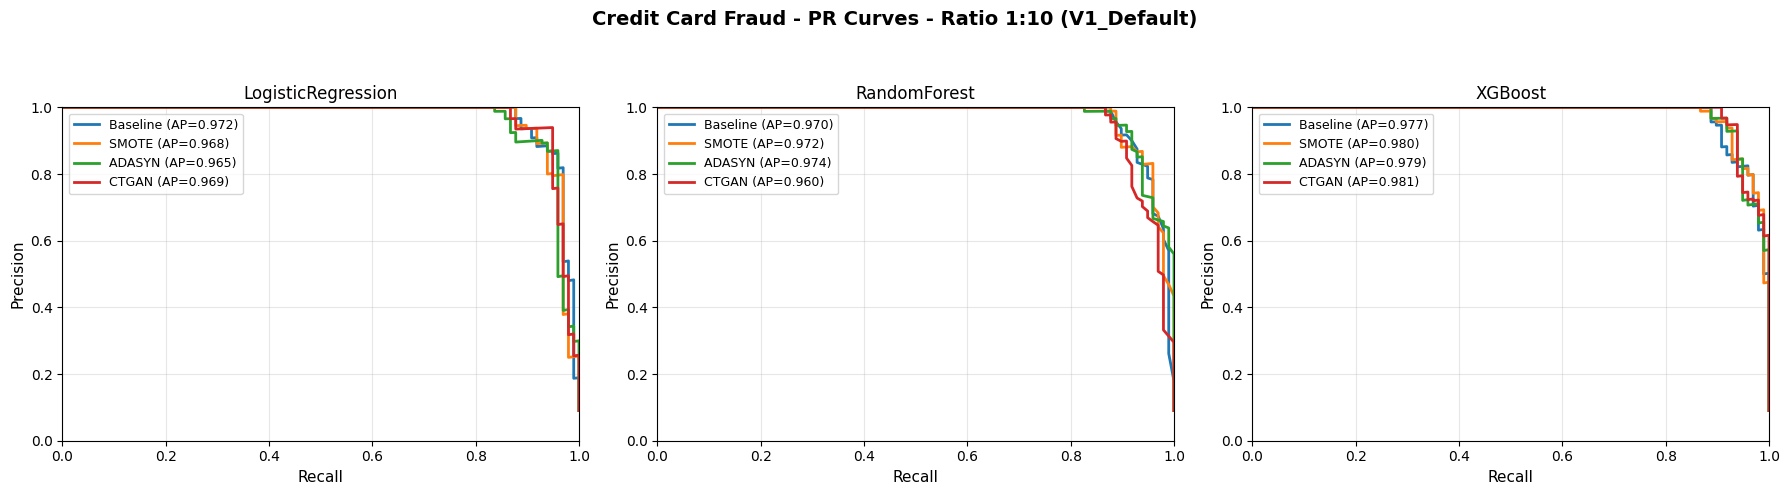

Saved PR curve: ratio 1:10, V1_Default


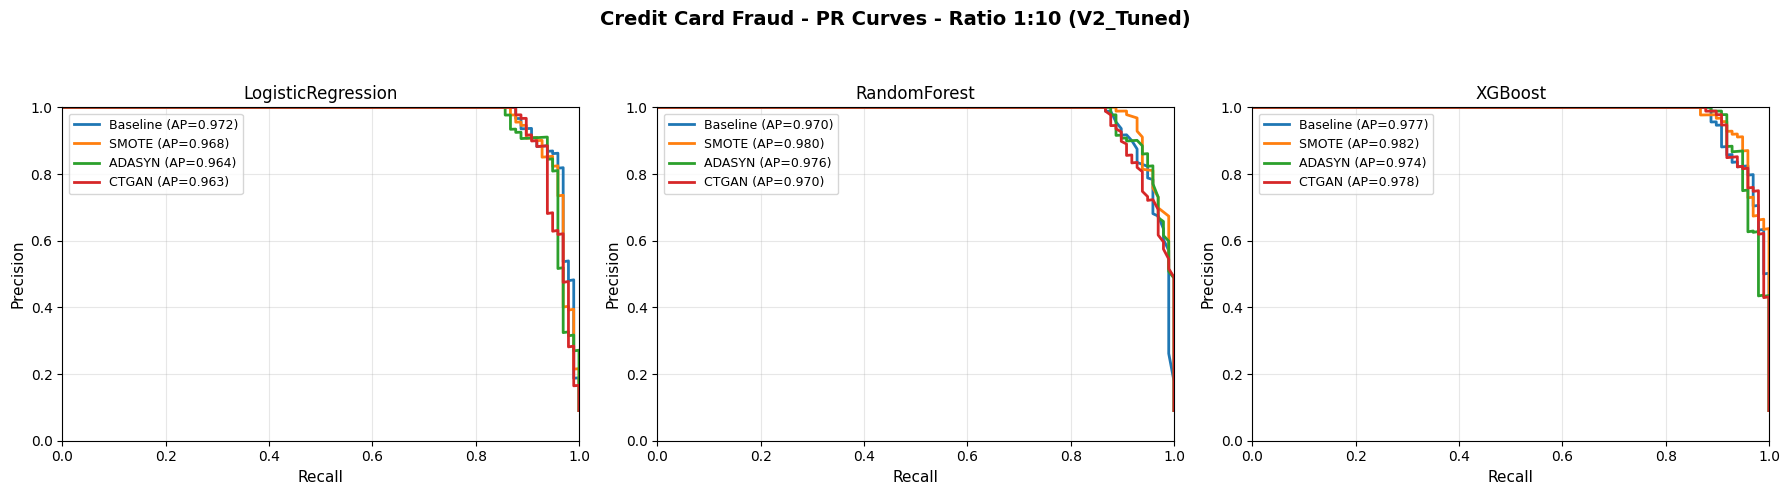

Saved PR curve: ratio 1:10, V2_Tuned


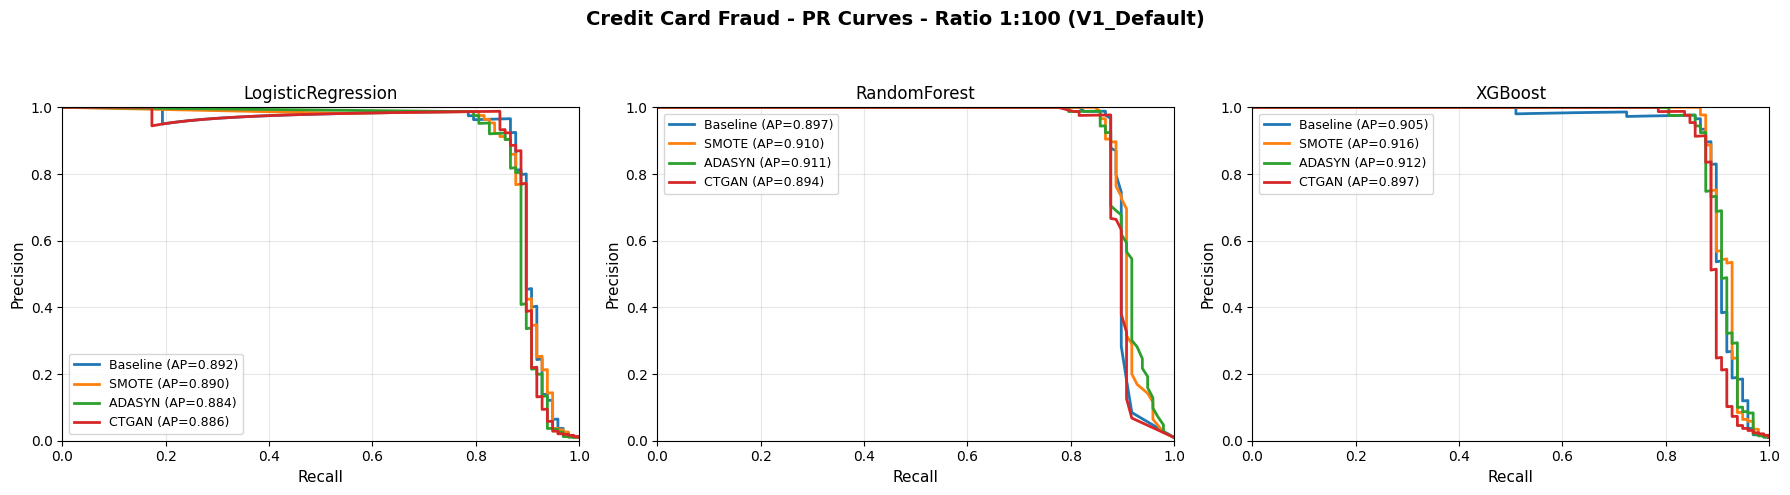

Saved PR curve: ratio 1:100, V1_Default


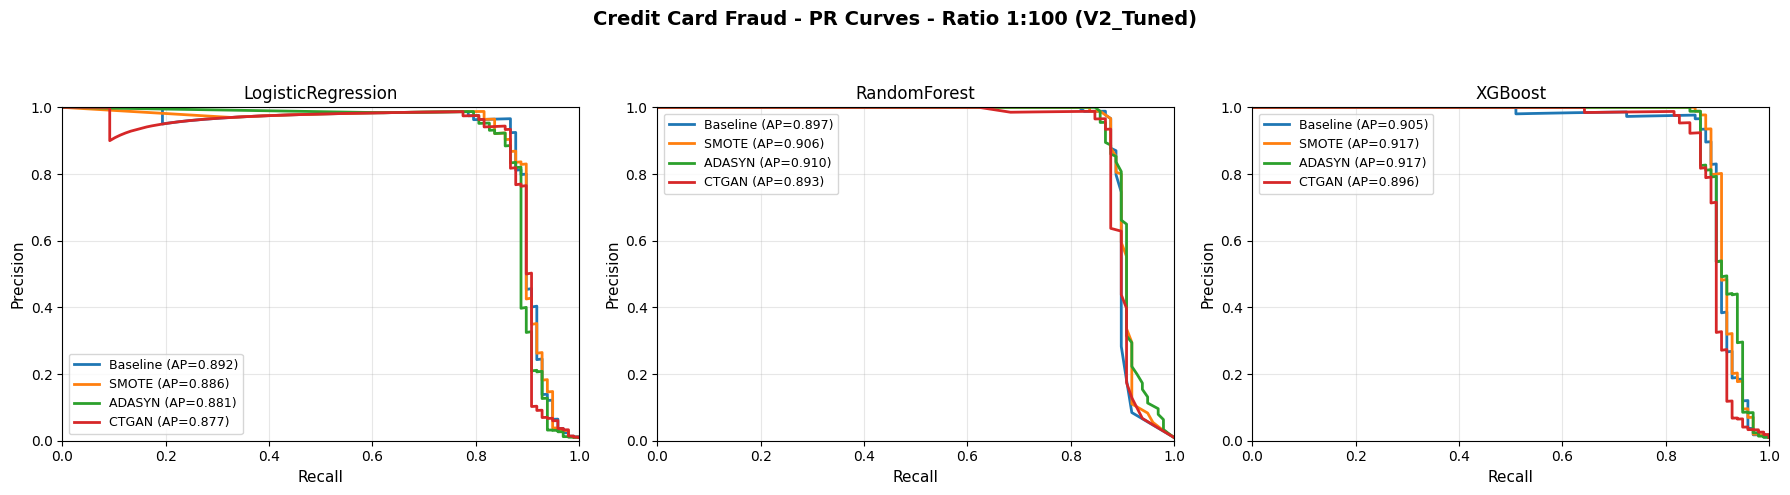

Saved PR curve: ratio 1:100, V2_Tuned


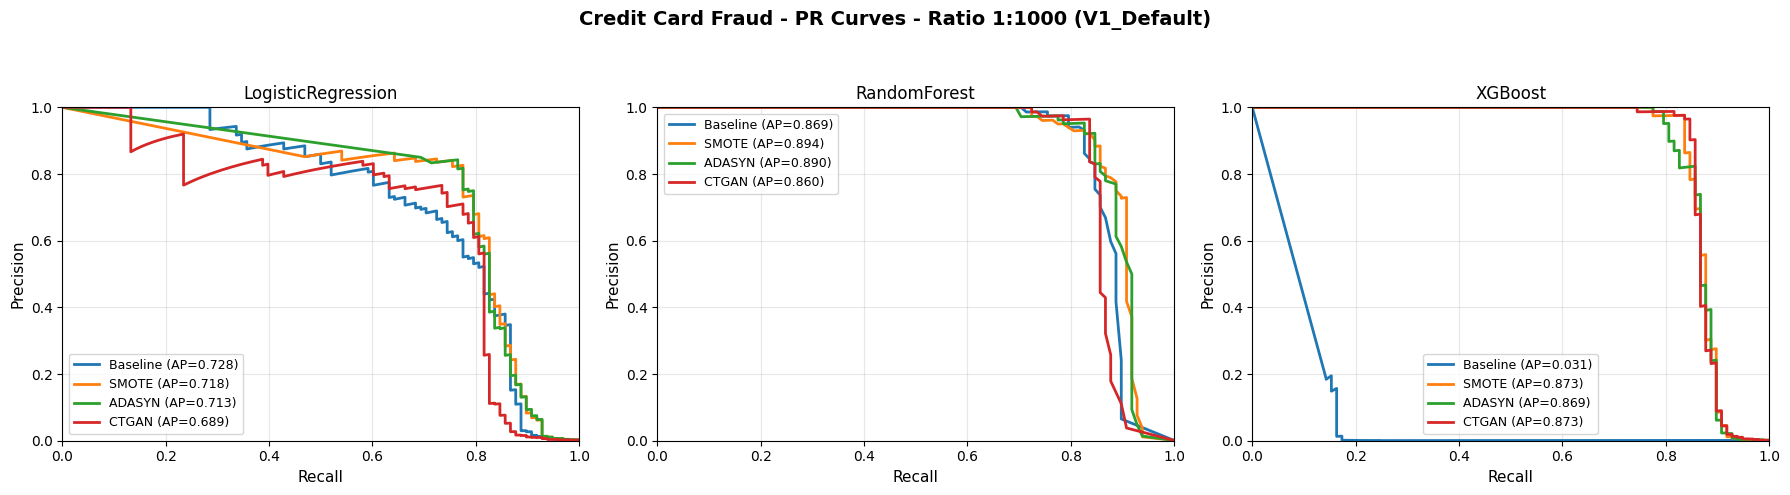

Saved PR curve: ratio 1:1000, V1_Default


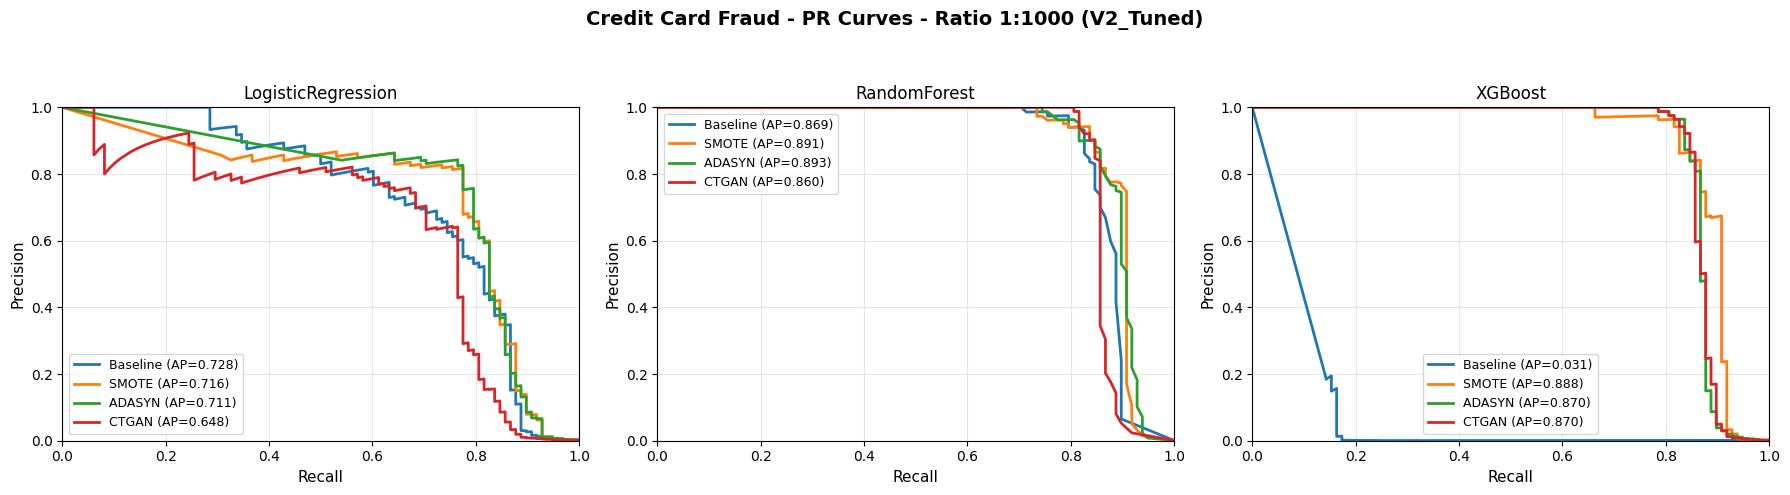

Saved PR curve: ratio 1:1000, V2_Tuned


In [24]:
os.makedirs('creditcard_results/plots_creditcard', exist_ok=True)

methods_list = ['Baseline', 'SMOTE', 'ADASYN', 'CTGAN']
classifiers_list = ['LogisticRegression', 'RandomForest', 'XGBoost']
method_colors = {'Baseline': '#1f77b4', 'SMOTE': '#ff7f0e', 'ADASYN': '#2ca02c', 'CTGAN': '#d62728'}

for ratio in ratios:
    ratio_key = f"1_{ratio}"
    pr_data = all_pr_curves[ratio_key]

    for variation in ['V1_Default', 'V2_Tuned']:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Credit Card Fraud - PR Curves - Ratio 1:{ratio} ({variation})', fontsize=14, fontweight='bold')

        for idx, clf_name in enumerate(classifiers_list):
            ax = axes[idx]
            for method in methods_list:
                if method in pr_data.get(variation, {}) and clf_name in pr_data[variation][method]:
                    pr_info = pr_data[variation][method][clf_name]
                    ax.plot(pr_info['recall'], pr_info['precision'],
                            label=f"{method} (AP={pr_info['ap']:.3f})",
                            color=method_colors[method], linewidth=2)

            ax.set_xlabel('Recall', fontsize=11)
            ax.set_ylabel('Precision', fontsize=11)
            ax.set_title(clf_name, fontsize=12)
            ax.legend(loc='best', fontsize=9)
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
            ax.grid(True, alpha=0.3)

        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.savefig(f'creditcard_results/plots_creditcard/pr_curves_1_{ratio}_{variation}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved PR curve: ratio 1:{ratio}, {variation}")

**9.2. F1 Delta - Improvement of SMOTE/ADASYN/CTGAN over Baseline**

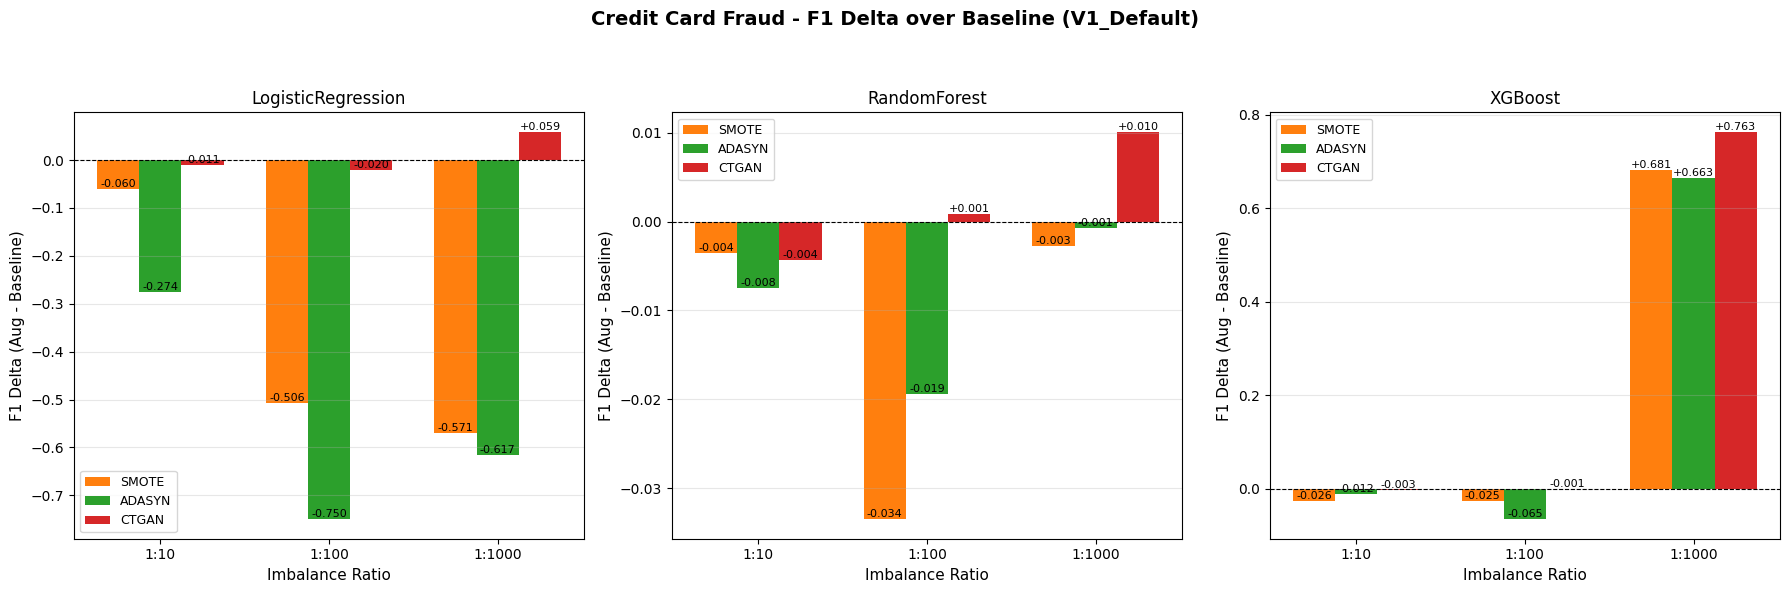

Saved F1 Delta chart: V1_Default


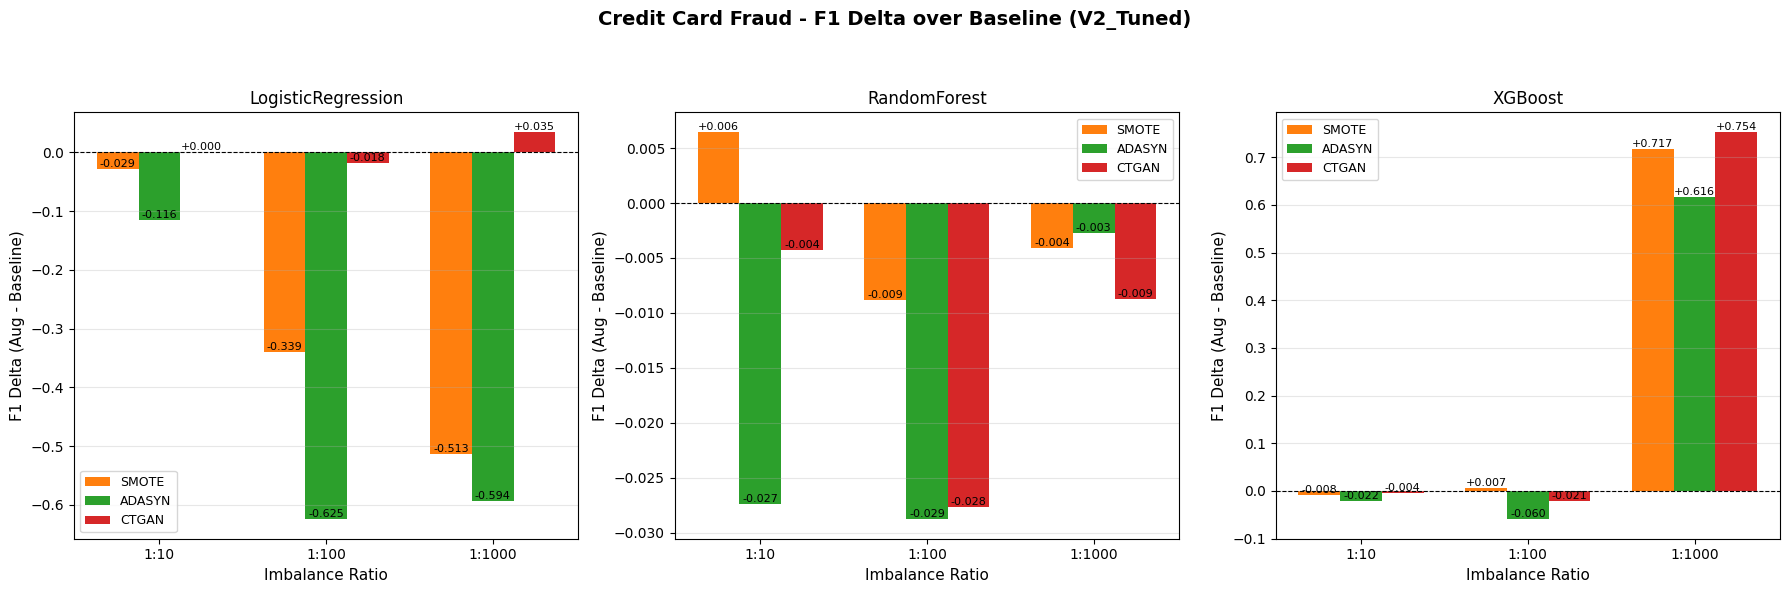

Saved F1 Delta chart: V2_Tuned


In [25]:
for variation in ['V1_Default', 'V2_Tuned']:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Credit Card Fraud - F1 Delta over Baseline ({variation})', fontsize=14, fontweight='bold')

    for idx, clf_name in enumerate(classifiers_list):
        ax = axes[idx]
        aug_methods = ['SMOTE', 'ADASYN', 'CTGAN']
        x_positions = np.arange(len(ratios))
        bar_width = 0.25

        for i, aug_method in enumerate(aug_methods):
            deltas = []
            for ratio in ratios:
                ratio_key = f"1_{ratio}"
                res = all_results[ratio_key]
                baseline_f1 = res[variation].get('Baseline', {}).get(clf_name, {}).get('F1', np.nan)
                aug_f1 = res[variation].get(aug_method, {}).get(clf_name, {}).get('F1', np.nan)
                delta = aug_f1 - baseline_f1 if not (np.isnan(aug_f1) or np.isnan(baseline_f1)) else 0
                deltas.append(delta)

            bars = ax.bar(x_positions + i * bar_width, deltas, bar_width,
                          label=aug_method, color=method_colors[aug_method])
            for bar, d in zip(bars, deltas):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f'{d:+.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_xlabel('Imbalance Ratio', fontsize=11)
        ax.set_ylabel('F1 Delta (Aug - Baseline)', fontsize=11)
        ax.set_title(clf_name, fontsize=12)
        ax.set_xticks(x_positions + bar_width)
        ax.set_xticklabels([f'1:{r}' for r in ratios])
        ax.legend(fontsize=9)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f'creditcard_results/plots_creditcard/f1_delta_{variation}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved F1 Delta chart: {variation}")

**9.3. F1 Scores Grouped Bar Charts**

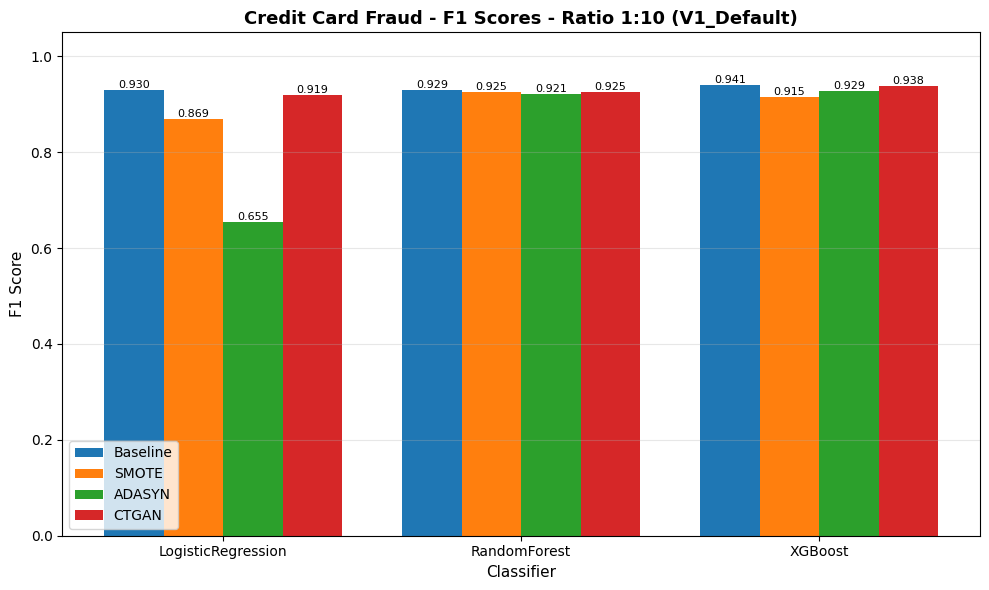

Saved F1 scores chart: ratio 1:10, V1_Default


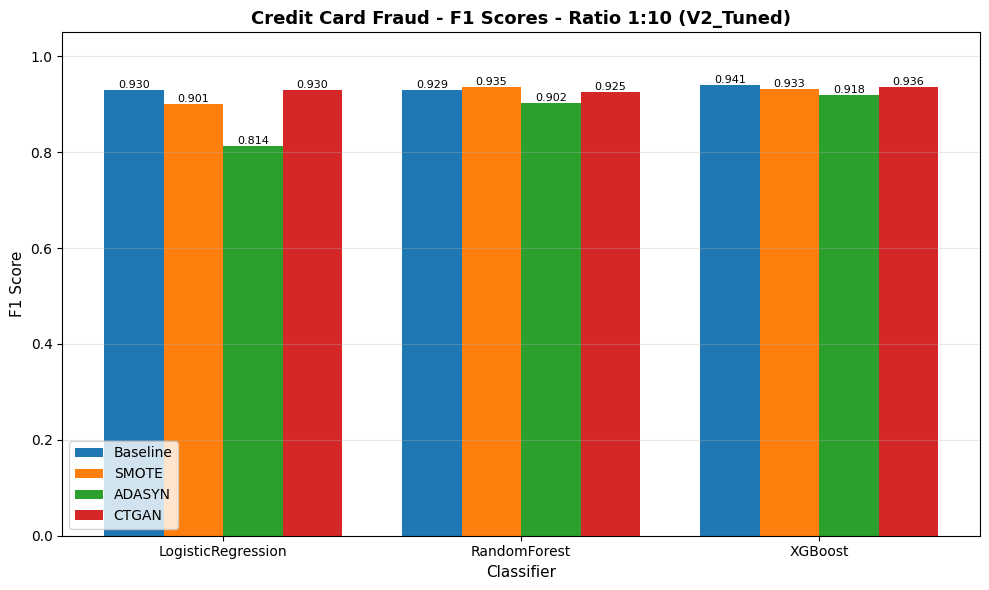

Saved F1 scores chart: ratio 1:10, V2_Tuned


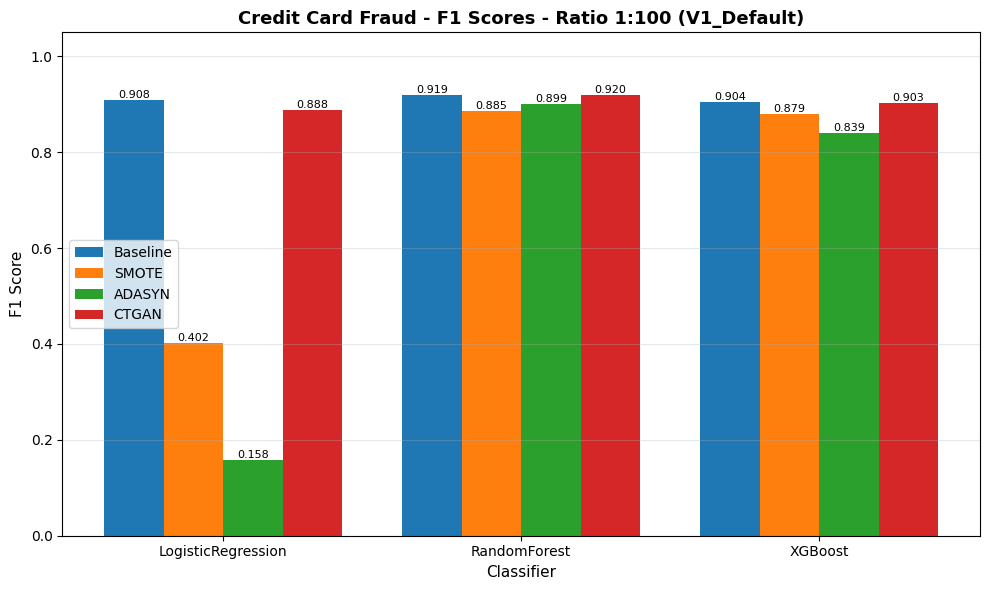

Saved F1 scores chart: ratio 1:100, V1_Default


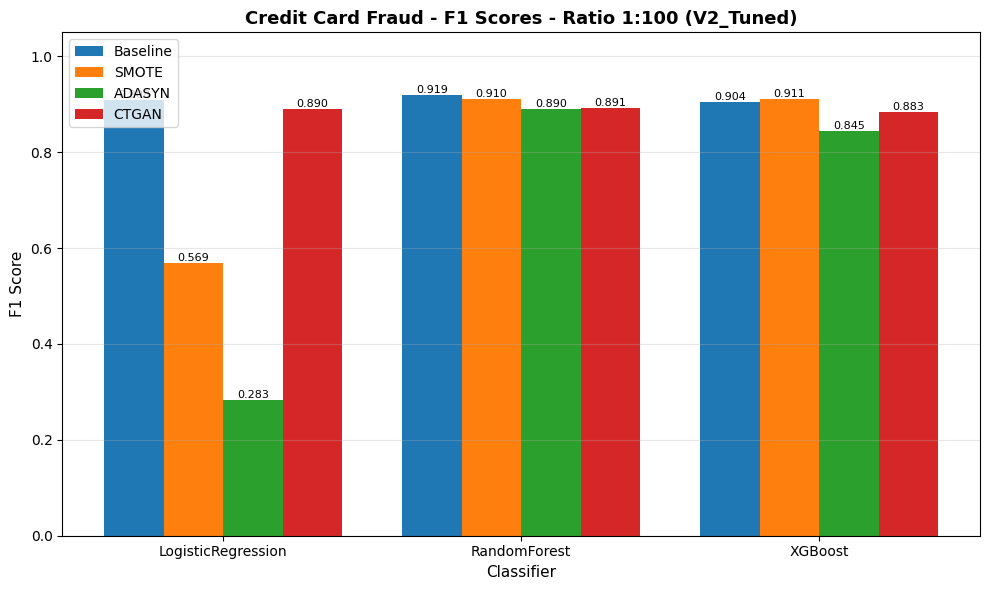

Saved F1 scores chart: ratio 1:100, V2_Tuned


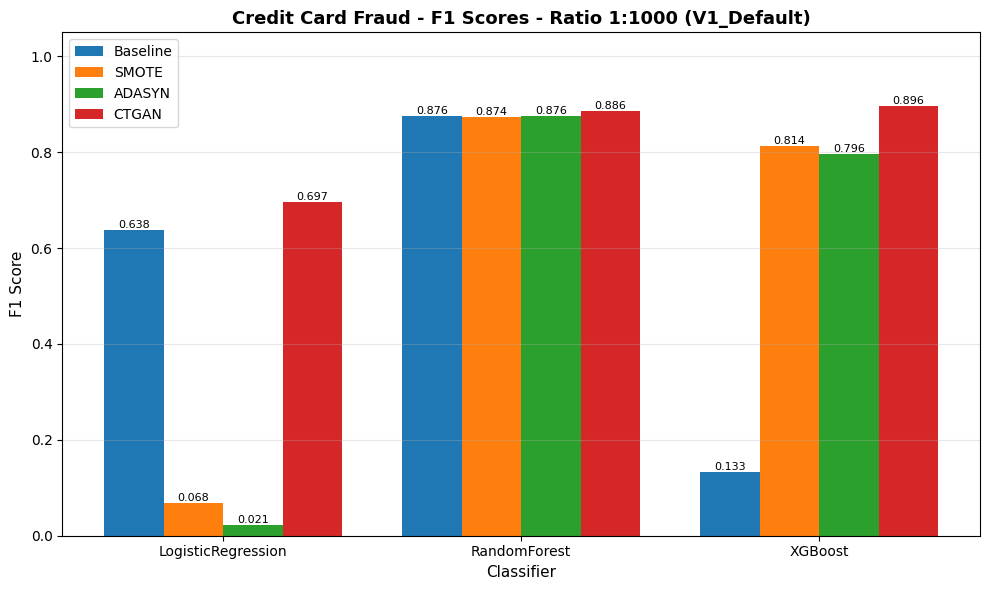

Saved F1 scores chart: ratio 1:1000, V1_Default


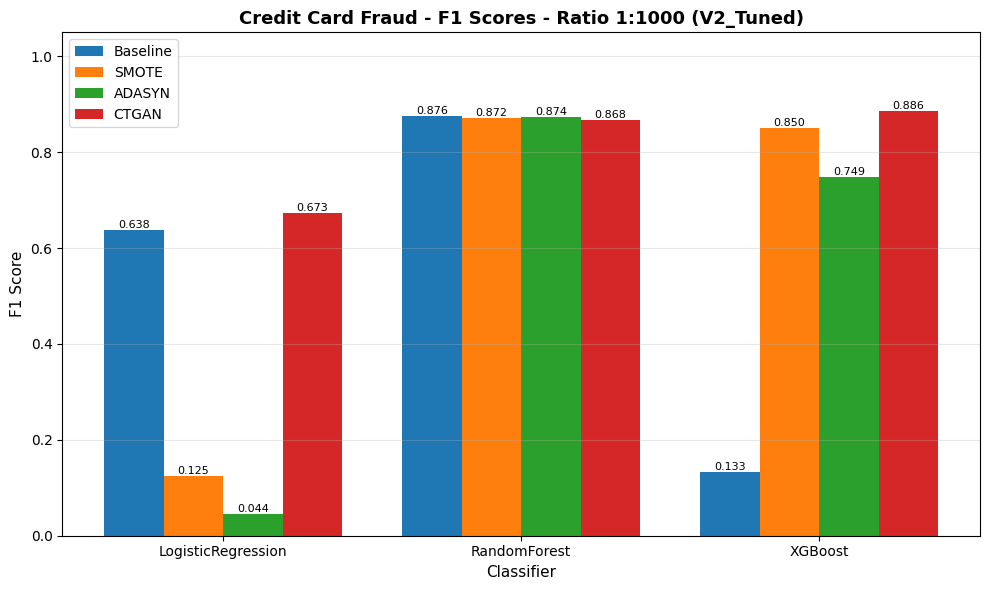

Saved F1 scores chart: ratio 1:1000, V2_Tuned


In [26]:
for ratio in ratios:
    ratio_key = f"1_{ratio}"
    res = all_results[ratio_key]

    for variation in ['V1_Default', 'V2_Tuned']:
        fig, ax = plt.subplots(figsize=(10, 6))
        x_positions = np.arange(len(classifiers_list))
        bar_width = 0.2

        for i, method in enumerate(methods_list):
            f1_scores = []
            for clf_name in classifiers_list:
                f1 = res[variation].get(method, {}).get(clf_name, {}).get('F1', 0)
                f1_scores.append(f1)
            bars = ax.bar(x_positions + i * bar_width, f1_scores, bar_width,
                          label=method, color=method_colors[method])
            for bar, val in zip(bars, f1_scores):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_xlabel('Classifier', fontsize=11)
        ax.set_ylabel('F1 Score', fontsize=11)
        ax.set_title(f'Credit Card Fraud - F1 Scores - Ratio 1:{ratio} ({variation})', fontsize=13, fontweight='bold')
        ax.set_xticks(x_positions + bar_width * 1.5)
        ax.set_xticklabels(classifiers_list)
        ax.legend(fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig(f'creditcard_results/plots_creditcard/f1_scores_1_{ratio}_{variation}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved F1 scores chart: ratio 1:{ratio}, {variation}")

**9.4. AUC-ROC Heatmaps**

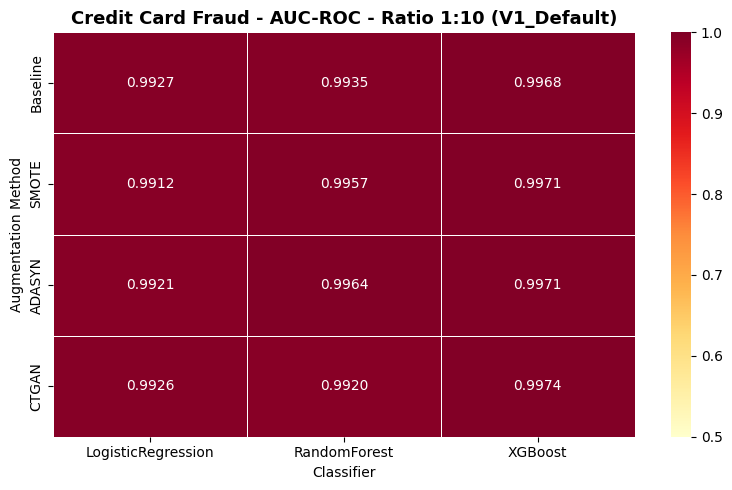

Saved AUC heatmap: ratio 1:10, V1_Default


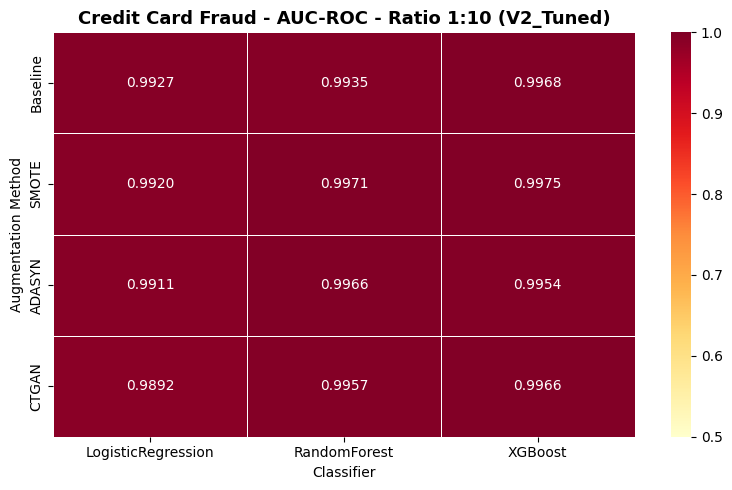

Saved AUC heatmap: ratio 1:10, V2_Tuned


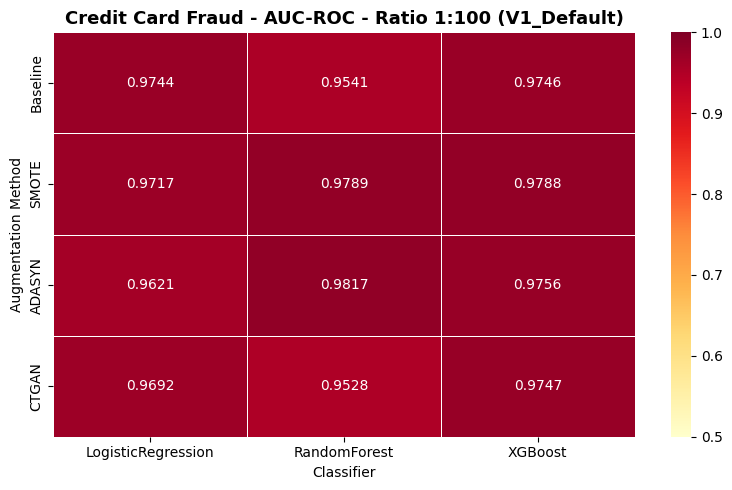

Saved AUC heatmap: ratio 1:100, V1_Default


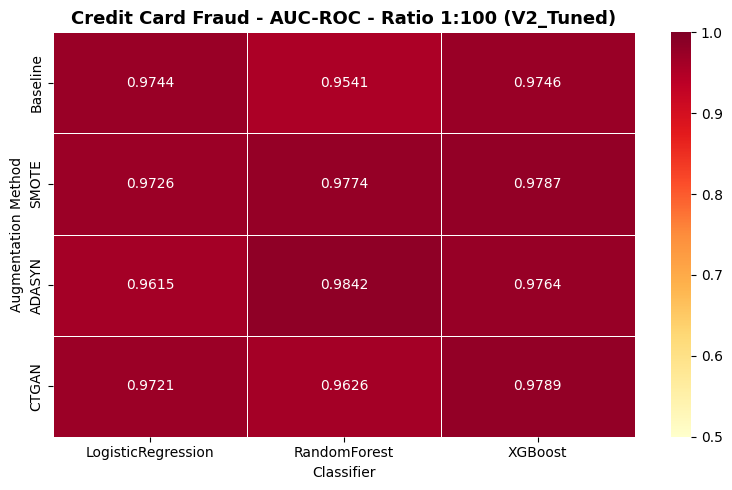

Saved AUC heatmap: ratio 1:100, V2_Tuned


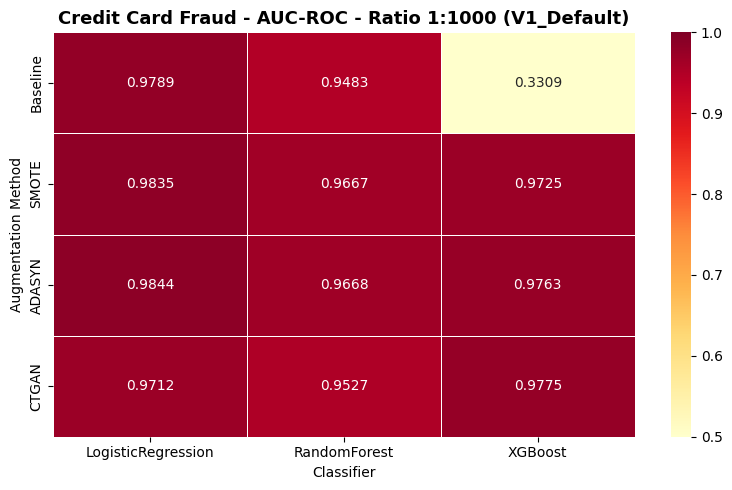

Saved AUC heatmap: ratio 1:1000, V1_Default


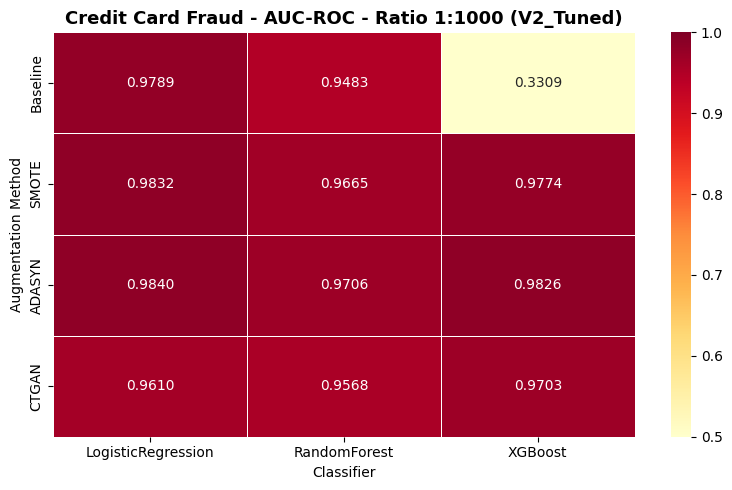

Saved AUC heatmap: ratio 1:1000, V2_Tuned


In [27]:
for ratio in ratios:
    ratio_key = f"1_{ratio}"
    res = all_results[ratio_key]

    for variation in ['V1_Default', 'V2_Tuned']:
        heatmap_data = pd.DataFrame(index=methods_list, columns=classifiers_list, dtype=float)
        for method in methods_list:
            for clf_name in classifiers_list:
                val = res[variation].get(method, {}).get(clf_name, {}).get('AUC-ROC', np.nan)
                heatmap_data.loc[method, clf_name] = val

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(heatmap_data.astype(float), annot=True, fmt='.4f', cmap='YlOrRd',
                    ax=ax, vmin=0.5, vmax=1.0, linewidths=0.5)
        ax.set_title(f'Credit Card Fraud - AUC-ROC - Ratio 1:{ratio} ({variation})', fontsize=13, fontweight='bold')
        ax.set_ylabel('Augmentation Method')
        ax.set_xlabel('Classifier')

        plt.tight_layout()
        plt.savefig(f'creditcard_results/plots_creditcard/auc_heatmap_1_{ratio}_{variation}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved AUC heatmap: ratio 1:{ratio}, {variation}")

**9.5. Precision vs Recall Scatter Plots**

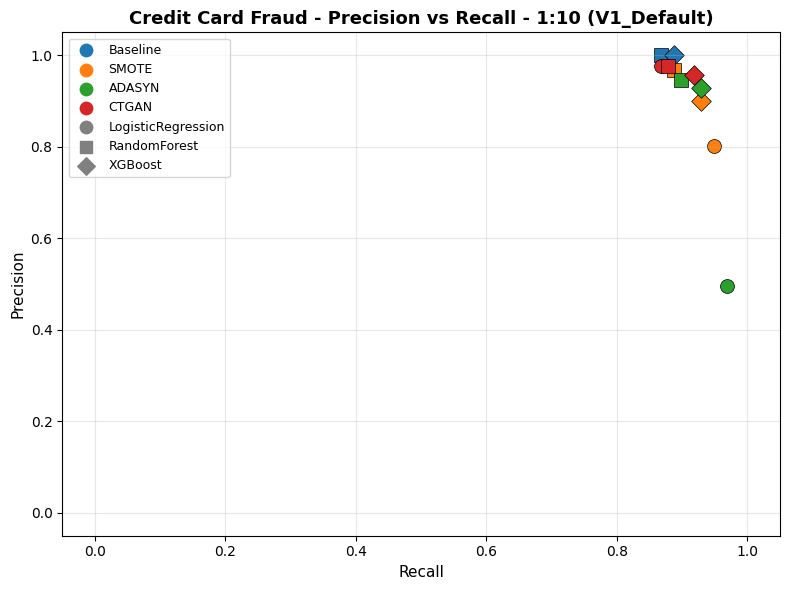

Saved Precision-Recall scatter: ratio 1:10, V1_Default


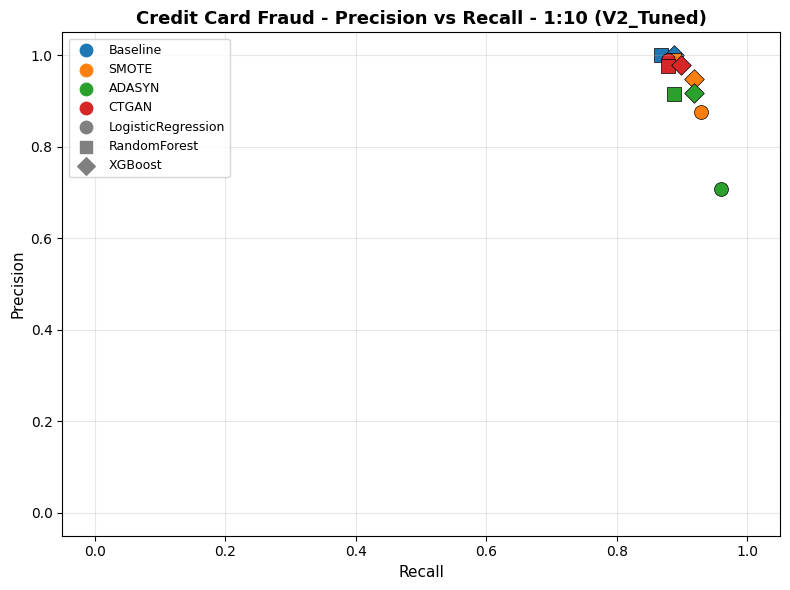

Saved Precision-Recall scatter: ratio 1:10, V2_Tuned


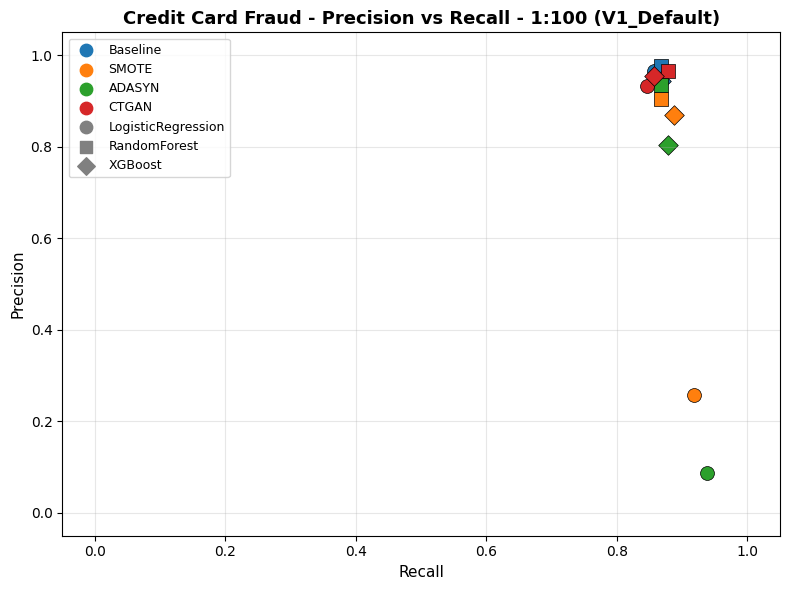

Saved Precision-Recall scatter: ratio 1:100, V1_Default


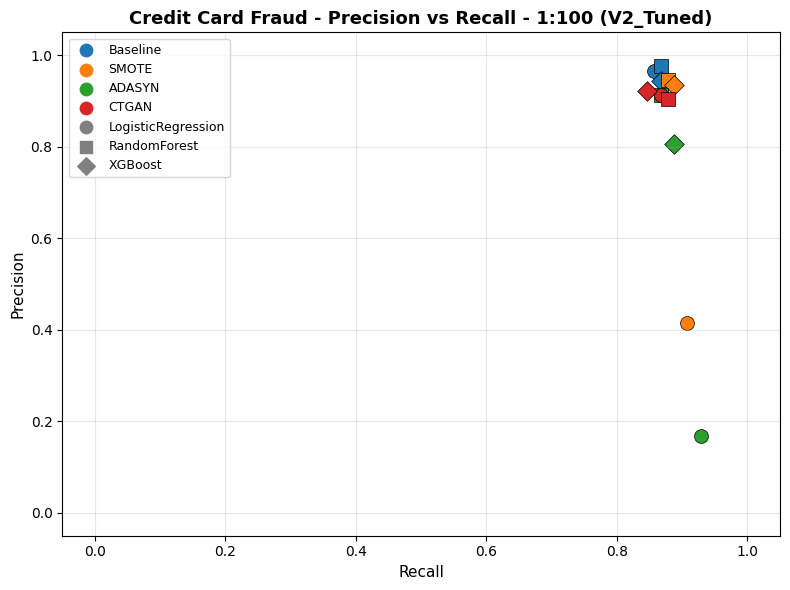

Saved Precision-Recall scatter: ratio 1:100, V2_Tuned


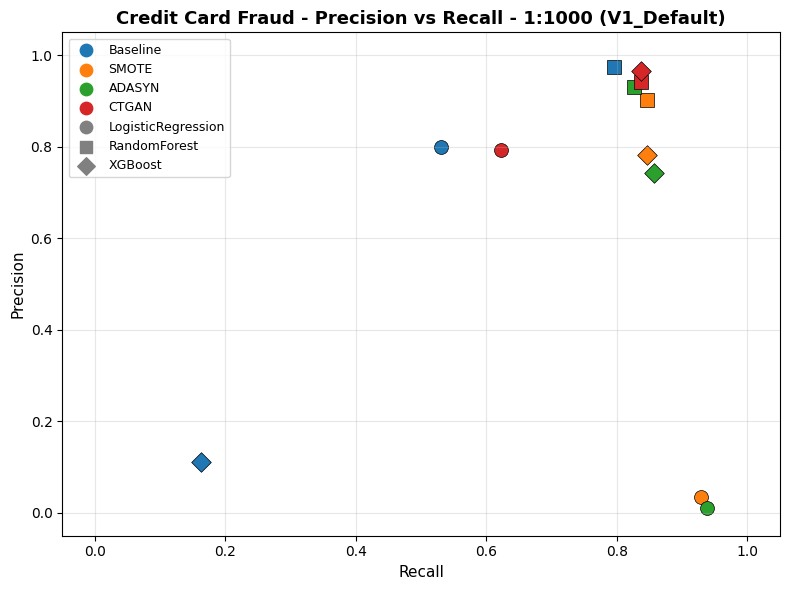

Saved Precision-Recall scatter: ratio 1:1000, V1_Default


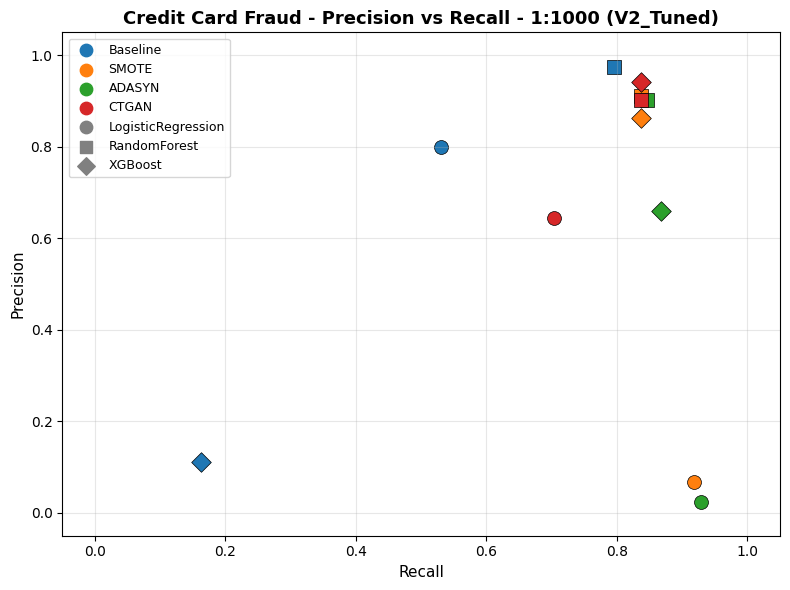

Saved Precision-Recall scatter: ratio 1:1000, V2_Tuned
CREDIT CARD FRAUD EXPERIMENTS COMPLETE


In [28]:
for ratio in ratios:
    ratio_key = f"1_{ratio}"
    res = all_results[ratio_key]

    for variation in ['V1_Default', 'V2_Tuned']:
        fig, ax = plt.subplots(figsize=(8, 6))
        marker_styles = {'LogisticRegression': 'o', 'RandomForest': 's', 'XGBoost': 'D'}

        for method in methods_list:
            for clf_name in classifiers_list:
                p = res[variation].get(method, {}).get(clf_name, {}).get('Precision', np.nan)
                r = res[variation].get(method, {}).get(clf_name, {}).get('Recall', np.nan)
                ax.scatter(r, p, color=method_colors[method], marker=marker_styles[clf_name],
                           s=100, edgecolors='black', linewidth=0.5)

        # Legend entries
        for method in methods_list:
            ax.scatter([], [], color=method_colors[method], label=method, s=80)
        for clf_name, marker in marker_styles.items():
            ax.scatter([], [], color='gray', marker=marker, label=clf_name, s=80)

        ax.set_xlabel('Recall', fontsize=11)
        ax.set_ylabel('Precision', fontsize=11)
        ax.set_title(f'Credit Card Fraud - Precision vs Recall - 1:{ratio} ({variation})', fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.set_xlim([-0.05, 1.05])
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'creditcard_results/plots_creditcard/precision_recall_scatter_1_{ratio}_{variation}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved Precision-Recall scatter: ratio 1:{ratio}, {variation}")

print("CREDIT CARD FRAUD EXPERIMENTS COMPLETE")
